# load packages

In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
import warnings
from muon import prot as pt

import sys
sys.path.append("./model/")

from train import train_SMAHD
from utils import set_seed

set_seed(2025)

warnings.filterwarnings('ignore')
# Environment configuration. SpatialGlue pacakge can be implemented with either CPU or GPU. GPU acceleration is highly recommend for imporoved efficiency.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# the location of R, which is required for the 'mclust' algorithm. Please replace the path below with local R installation path
os.environ['R_HOME'] = "/usr/lib/R/"


# load data

In [2]:
path="datasets/simulated_datasets/"
adata1 = sc.read_h5ad(path + 'adata_omics1_405k.h5ad')
adata2 = sc.read_h5ad(path + 'adata_omics2_405k.h5ad')

# Spatial neighbour graph construction

In [3]:
from model.utils import Cal_Spatial_Net
Cal_Spatial_Net(adata1, model="KNN", n_neighbors=25)

The graph contains 10125450 edges, 405018 cells.
25.0000 neighbors per cell on average.


In [4]:
from muon import atac as ac
from model.utils import pca

adata1.obsm['feat'] = pca(adata1, n_comps=30)
adata2.obsm['feat'] = pca(adata2, n_comps=30)

# Model training and Clustering

In [5]:
from layer import SMAHD,GCNConv_Encoder,GCNConv_Decoder,GATConv_Encoder,GATConv_Decoder,SAGEConv_Encoder,SAGEConv_Decoder

adata_list=[adata1,adata2]
x = [torch.FloatTensor(adata.obsm['feat']) for adata in adata_list]
edge =torch.LongTensor(adata1.uns["edgeList"])

adata1.obsm["SMAHD"]=train_SMAHD(features=x,
            edge=edge,
            weights=[1,1],
            emb_dim=64, 
            train_batch_size=100000,
            infer_batch_size=500000,      
            n_epochs=100,
            lr=0.005,
            weight_decay=1e-6,
            train_device = device,
            infer_device=torch.device('cpu'),
            Conv_Encoder=GCNConv_Encoder,
            Conv_Decoder=GCNConv_Decoder)

from utils import clustering
from sklearn.metrics import adjusted_rand_score

tool = 'mclust'  # mclust, leiden, and louvain
clustering(adata1, key='SMAHD', add_key='SMAHD', n_clusters=5, method=tool, use_pca=True)
ari = adjusted_rand_score(adata1.obs['mark_area'], adata1.obs['SMAHD'])
print(ari)

Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [01:30<00:00,  1.10it/s, loss=129]
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
0.9841008535890765


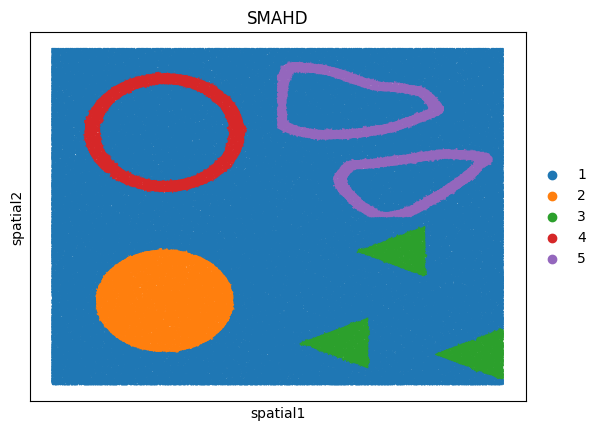

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
sc.pl.embedding(adata1, basis='spatial', color='SMAHD',  title='SMAHD', s=5)
plt.savefig("/home/dwang/SMAHD/Figure/simulated_SMAHD.jpg", dpi=1200, bbox_inches='tight')
plt.show()

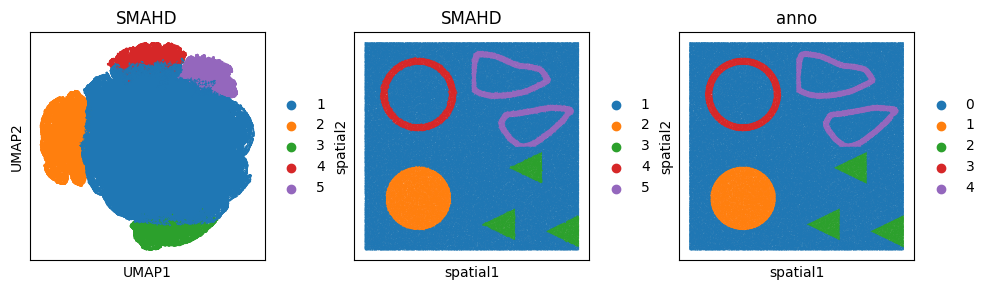

In [7]:
import matplotlib.pyplot as plt
adata=adata1
fig, ax_list = plt.subplots(1, 3, figsize=(10, 3))
sc.pp.neighbors(adata, use_rep='SMAHD', n_neighbors=10)
sc.tl.umap(adata)

sc.pl.umap(adata, color='SMAHD', ax=ax_list[0], title='SMAHD', s=5, show=False)
sc.pl.embedding(adata, basis='spatial', color='SMAHD', ax=ax_list[1], title='SMAHD', s=1, show=False)
sc.pl.embedding(adata, basis='spatial', color='mark_area', ax=ax_list[2], title='anno', s=1, show=False)
plt.tight_layout(w_pad=0.3)
plt.savefig("/home/dwang/SMAHD/Figure/simu_ANNO.jpg", dpi=1200, bbox_inches='tight')